In [1]:
%load_ext autoreload
%autoreload 2

# COFFEE & SLEEP — Fatores associados à qualidade do sono
## Análise Exploratória, Testes Estatísticos e Modelagem
Metodologia: CRISP-DM

1. Definição do problema
2. Compreensão dos dados
3. Preparação dos dados
4. Modelagem
5. Avaliação

# **1. DEFINIR O PROBLEMA DE NEGÓCIO**

- **Pergunta:** quais fatores de estilo de vida estão associados à qualidade do sono, e é possível prevê-la a partir deles?

- **Alvo:** Sleep_Quality (Poor, Fair, Good, Excellent).

- O dataset contém 10.000 registros sintéticos relacionando consumo de café, hábitos de sono e indicadores de saúde em 20 países.

Fonte: https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset

## **1.1 IMPORTANDO BIBLIOTECAS**

In [ ]:
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb

from pandas.api.types import CategoricalDtype
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

from projeto import visualizer as vizu
from projeto import testes

CAMINHO = "/data/PROJETOS/GIT/COFFEE-SLEEP/data/raw/synthetic_coffee_health_10000(in).csv"
ALVO    = "Sleep_Quality"
CLASSES = ["Poor", "Fair", "Good", "Excellent"]

# **2. COMPREENSÃO DOS DADOS**

- O dataset foi coletado em: https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset

- O conjunto de dados GlobalCoffeeHealth contém 10.000 registros sintéticos que refletem padrões reais de consumo de café, comportamento do sono e indicadores de saúde em 20 países. Ele abrange dados demográficos, ingestão diária de café, níveis de cafeína, duração e qualidade do sono, IMC, frequência cardíaca, estresse, atividade física, problemas de saúde, ocupação, tabagismo e consumo de álcool.

- O conjunto de dados captura correlações realistas observadas em pesquisas — como o impacto da cafeína no sono, no estresse e na saúde —, tornando-o ideal para análises estatísticas, modelagem preditiva e estudos sobre estilo de vida ou bem-estar.

## **2.1 COLETA E INTEGRAÇÃO INICIAL DE DADOS**

In [3]:
df = pd.read_csv(CAMINHO)


df["Sleep_Quality"] = df["Sleep_Quality"].astype(CategoricalDtype(CLASSES, ordered=True))
df["Stress_Level"]  = df["Stress_Level"].astype(CategoricalDtype(["Low", "Medium", "High"], ordered=True))
df["Health_Issues"] = df["Health_Issues"].astype(CategoricalDtype(["Mild", "Moderate", "Severe"], ordered=True))

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/synthetic_coffee_health_10000(in).csv'

## **2.2 ANÁLISE DESCRITIVA**


- **ID**   Integer	Identificador único de cada registro (1–10000).
- **Age**	Integer	Idade do participante (18 a 80 anos).
- **Gender**	Categorical	Gênero: Male, Female ou Other.
- **Country**	Categorical	País de residência (20 países representados).
- **Coffee_Intake**	Float	Consumo diário de café em xícaras (0 a 10).
- **Caffeine_mg**	Float	Estimativa de cafeína ingerida por dia em mg (1 xícara ≈ 95 mg).
- **Sleep_Hours**	Float	Média de horas de sono por noite (3 a 10 horas).
- **Sleep_Quality**	Categorical	Qualidade do sono: Poor, Fair, Good ou Excellent.
- **BMI**	Float	Índice de Massa Corporal (15 a 40).
- **Heart_Rate**	Integer	Frequência cardíaca em repouso (50 a 110 bpm).
- **Stress_Level**	Categorical	Nível de estresse: Low, Medium ou High.
- **Physical_Activity_Hours**	Float	Tempo de atividade física semanal em horas (0 a 15).
- **Health_Issues**	Categorical	Condições de saúde: None, Mild, Moderate ou Severe.
- **Occupation**	Categorical	Ocupação principal: Office, Healthcare, Student, Service, Other.
- **Smoking**	Boolean	Fumante: 0 = Não, 1 = Sim.
- **Alcohol_Consumption**	Boolean	Consome álcool: 0 = Não, 1 = Sim.

In [ ]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print(f"Duplicados: {df.duplicated().sum()}\n")

nulos = df.isna().sum()
print(nulos[nulos > 0].to_string() if nulos.any() else "Sem valores nulos.")

Linhas: 10000
Colunas: 16
Duplicados: 0

Health_Issues    5941


## **2.3 ANÁLISE EXPLORATÓRIA**

In [ ]:
variaveis_numericas = [
    col for col in df.select_dtypes(include="number").columns
    if df[col].nunique() > 2 and col != "ID"
]
variaveis_binarias = [col for col in df.columns if df[col].nunique() == 2]

variaveis_textuais = [
    col for col in df.select_dtypes(include=["object", "category"]).columns
    if df[col].nunique() > 2
]
variaveis_categoricas = variaveis_textuais + variaveis_binarias

print("Numéricas:  ", variaveis_numericas)
print("Categóricas:", variaveis_categoricas)

Numéricas:   ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours']
Categóricas: ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Health_Issues', 'Occupation', 'Smoking', 'Alcohol_Consumption']


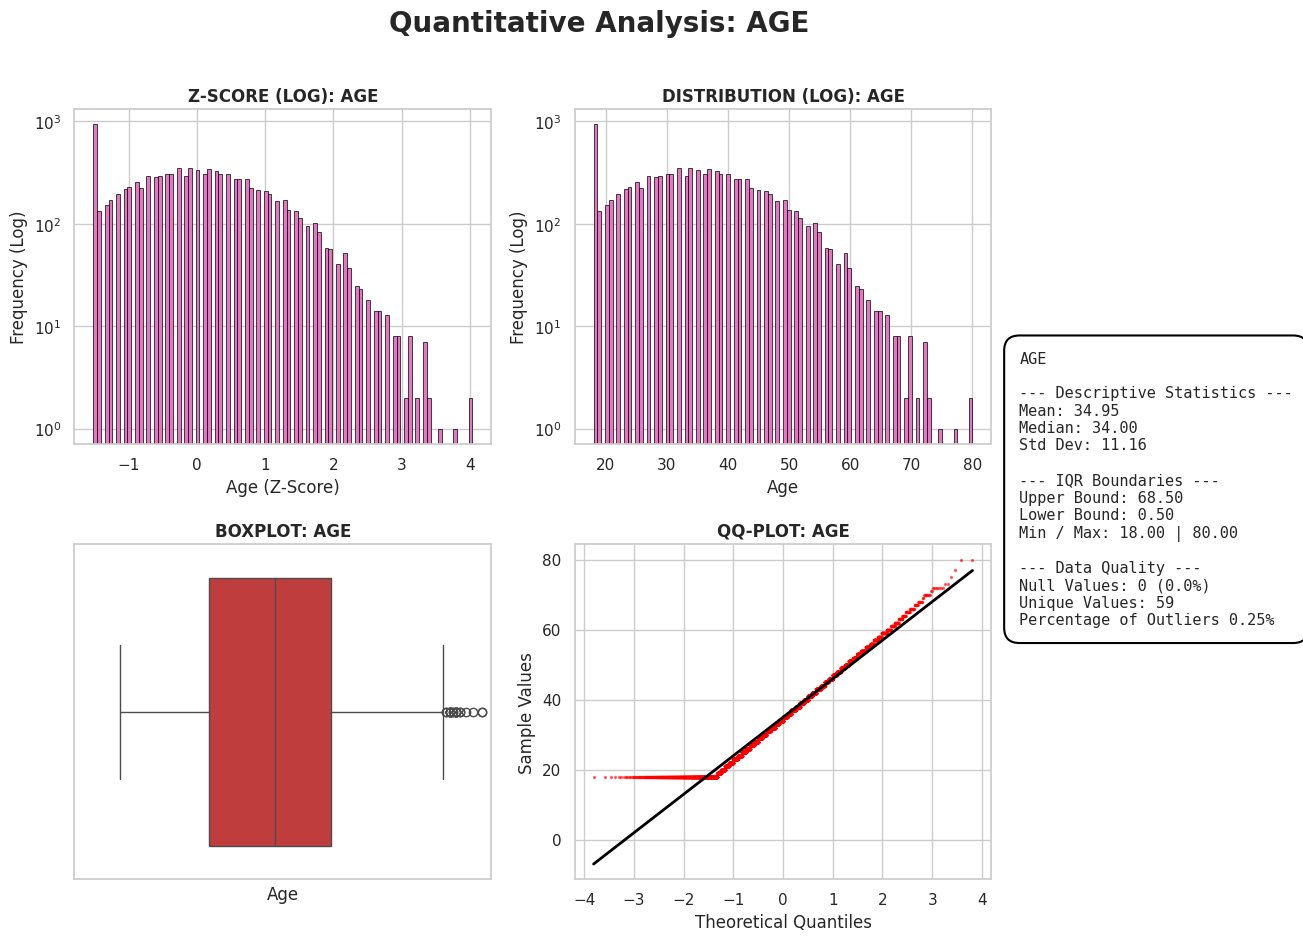

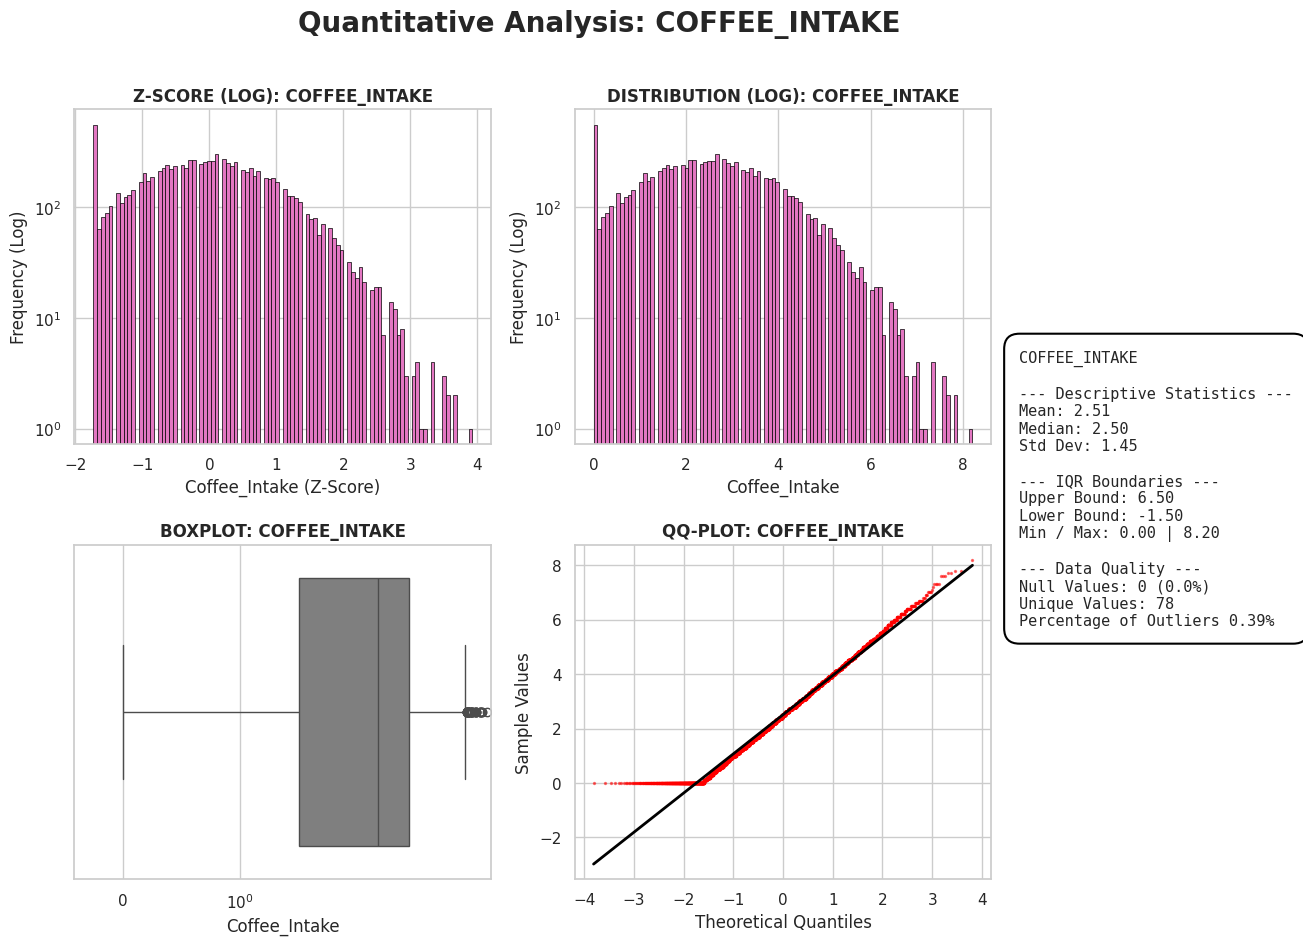

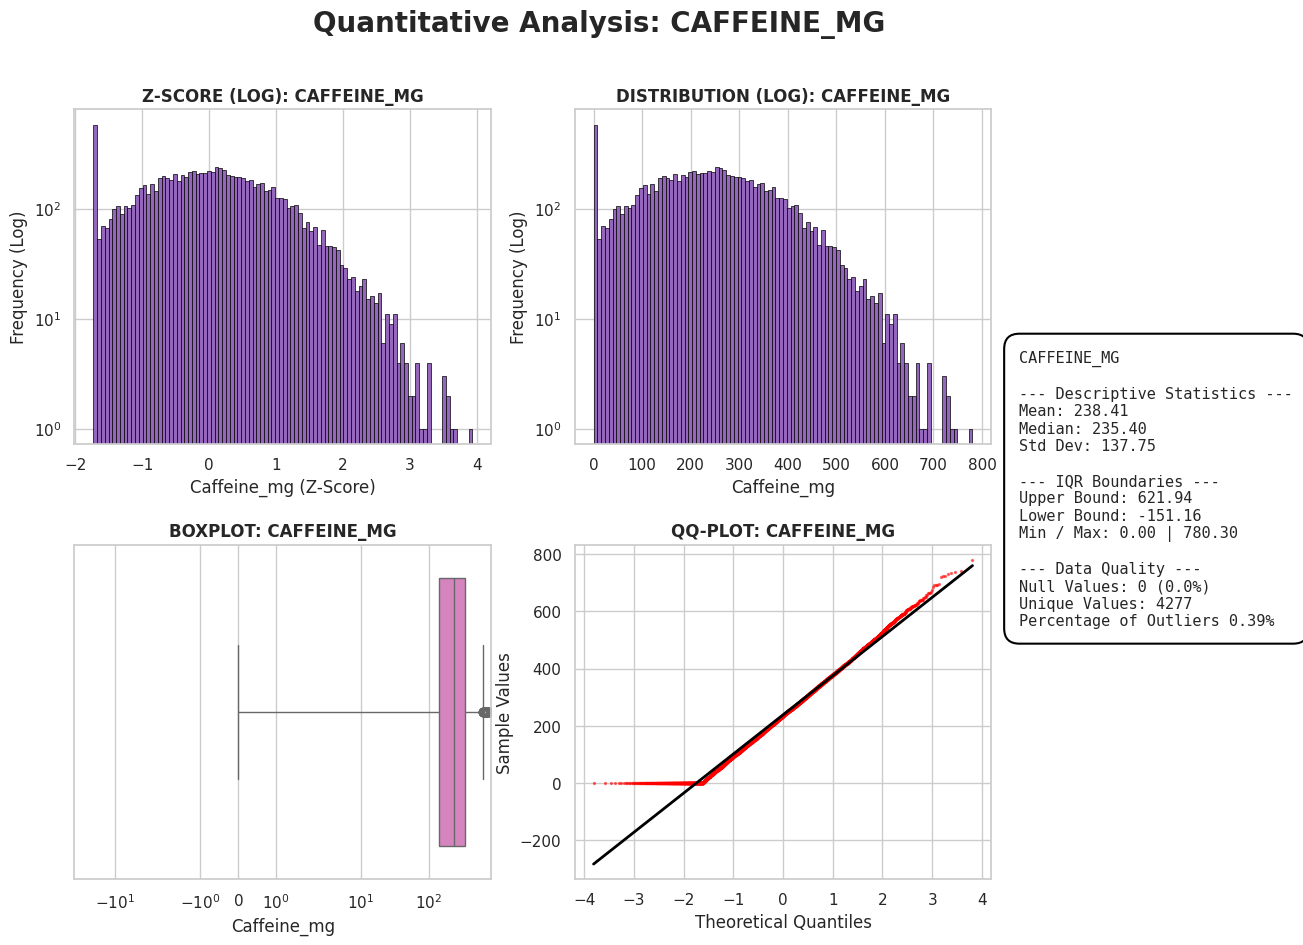

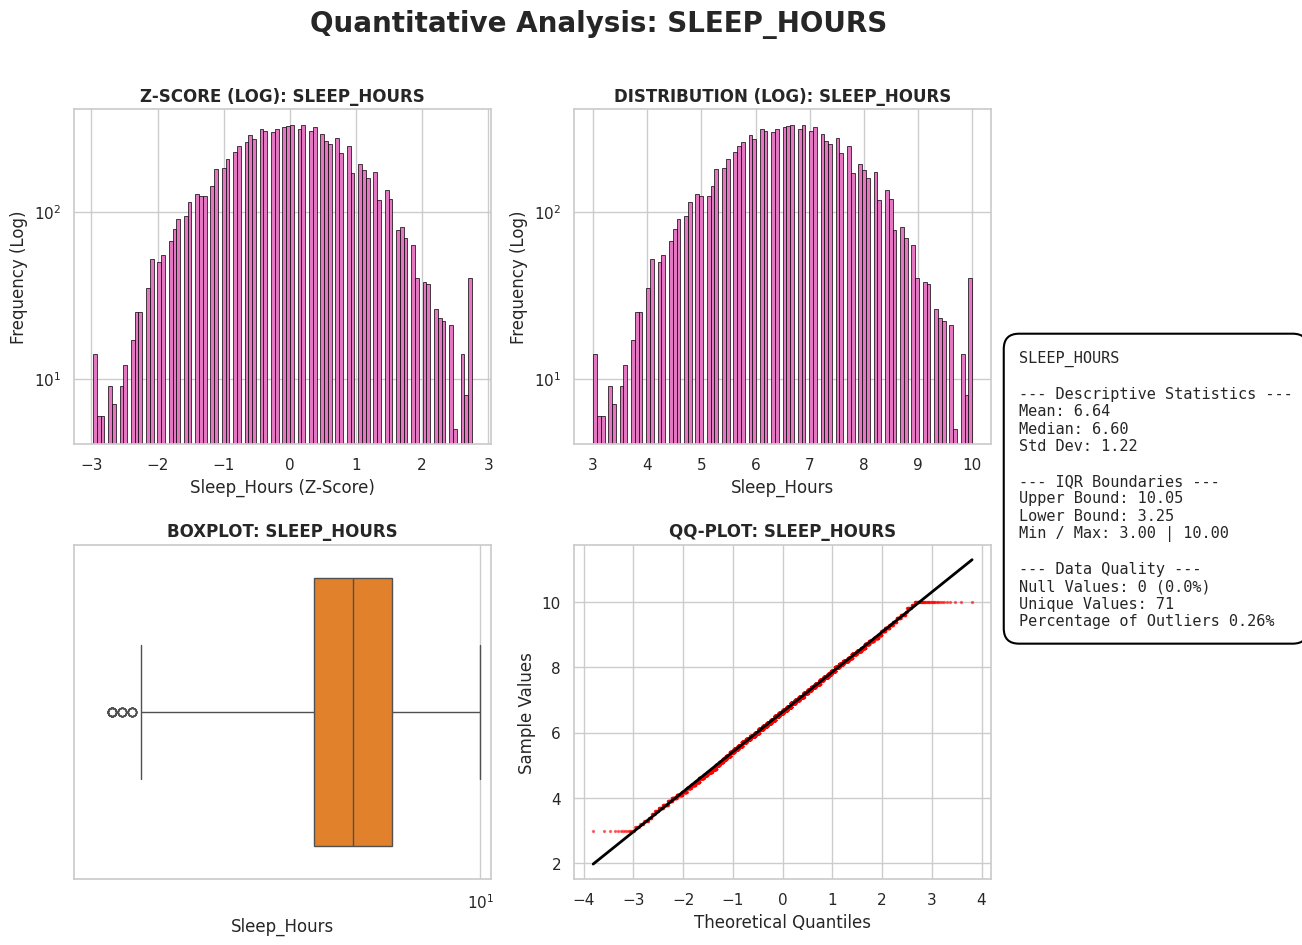

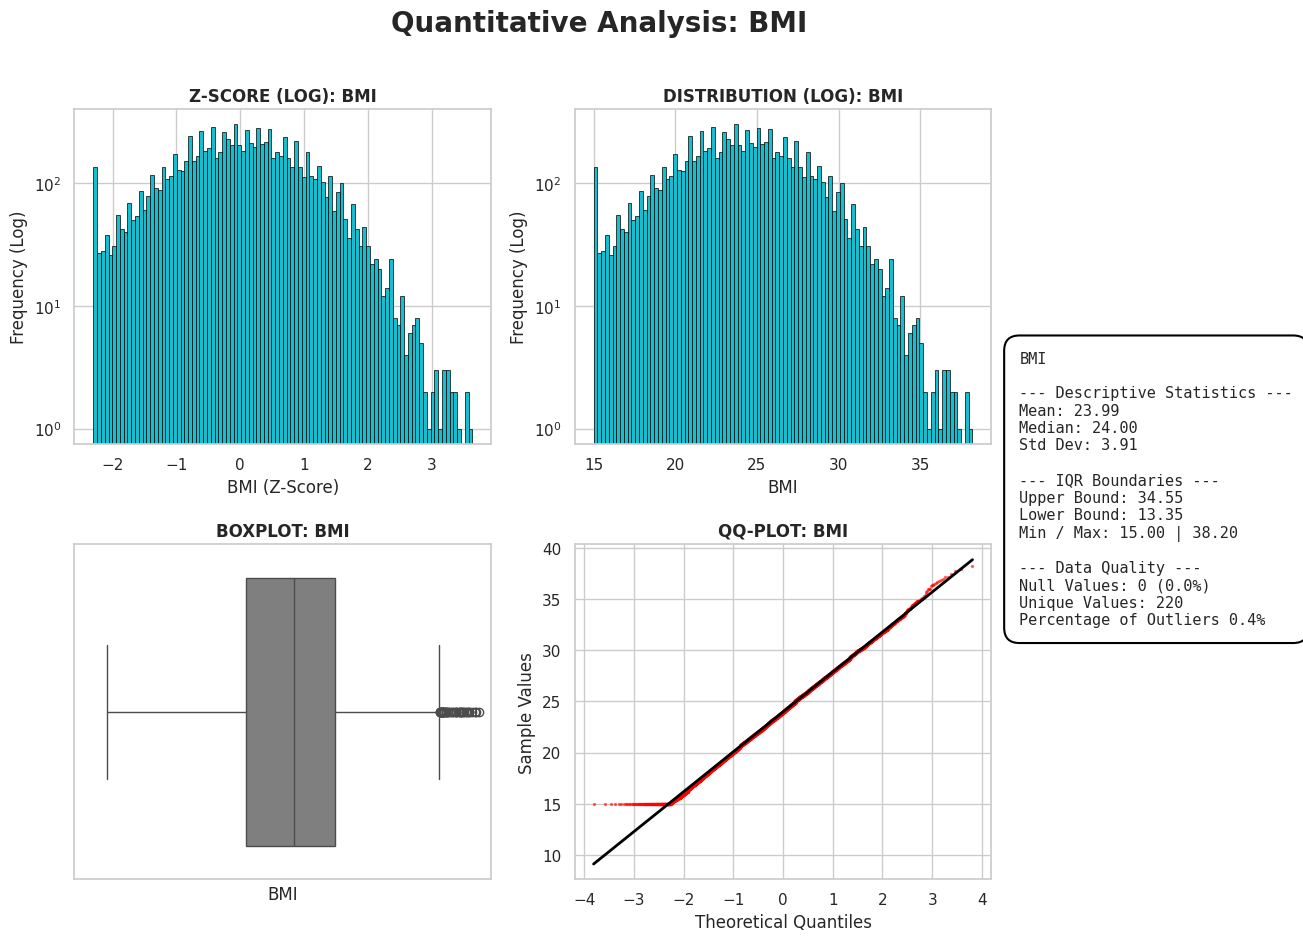

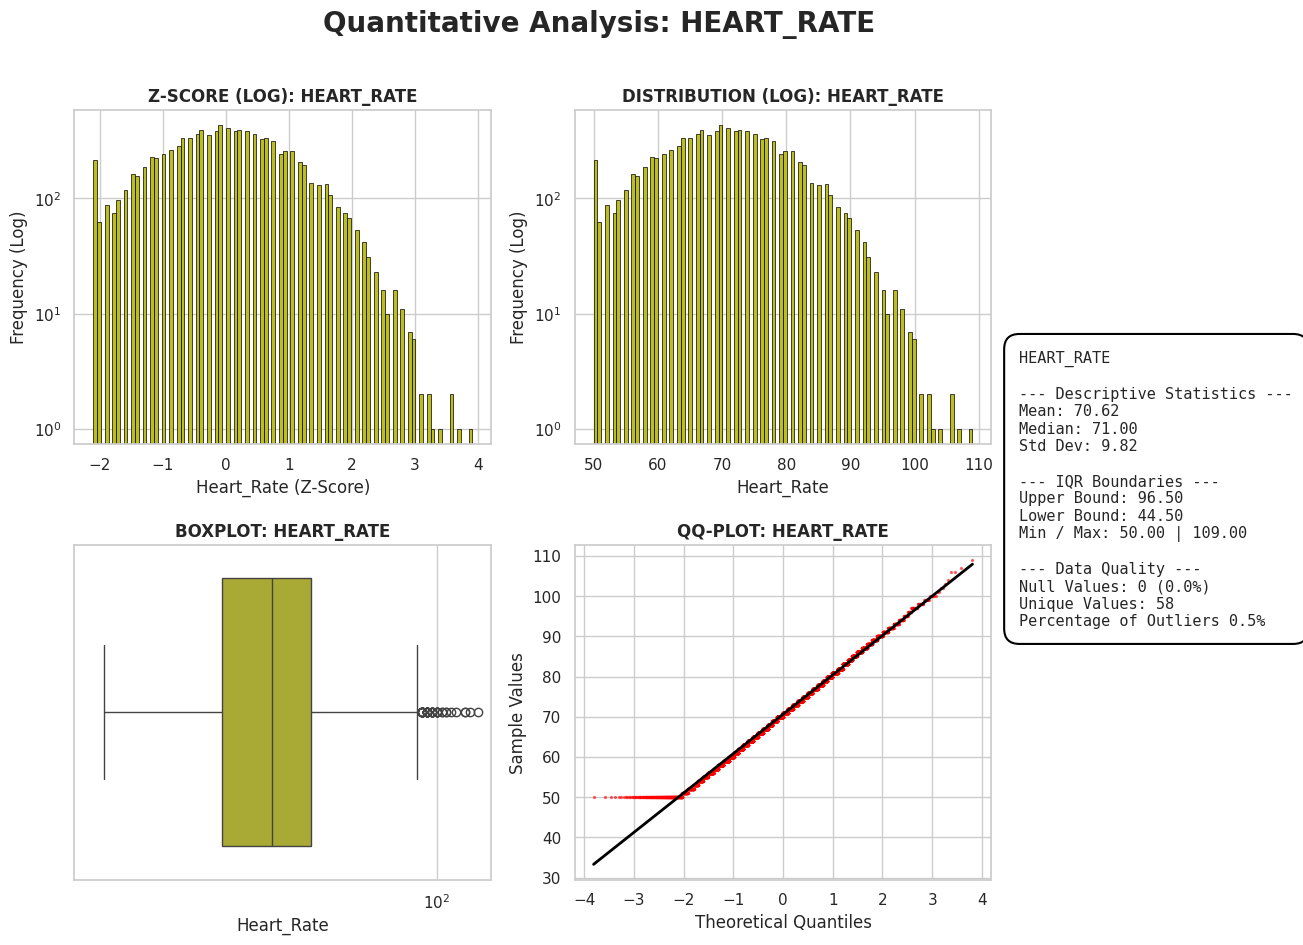

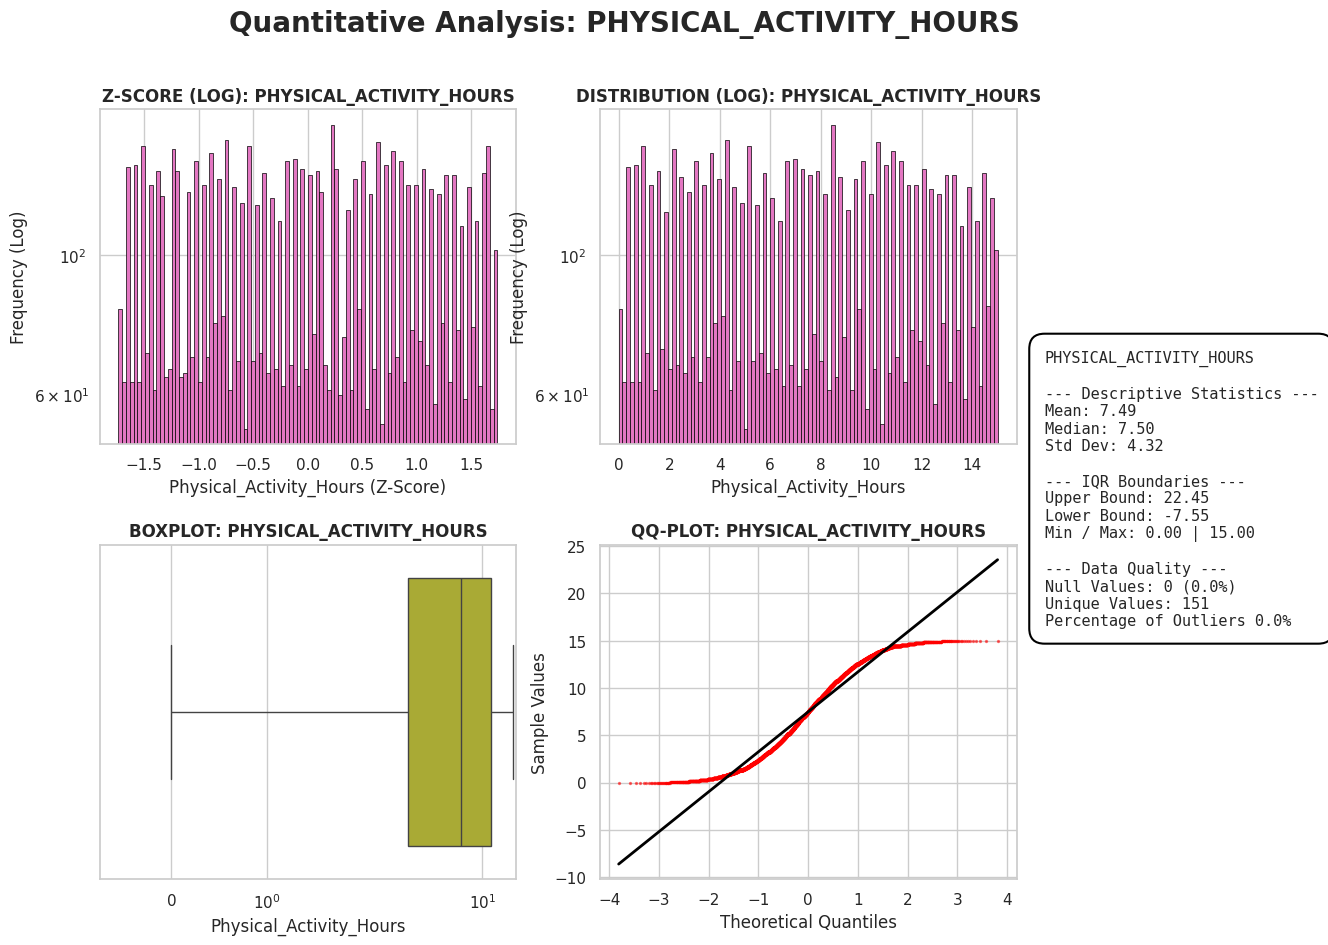

In [ ]:
vizu.generate_quantitative_panel(df, variaveis_numericas)

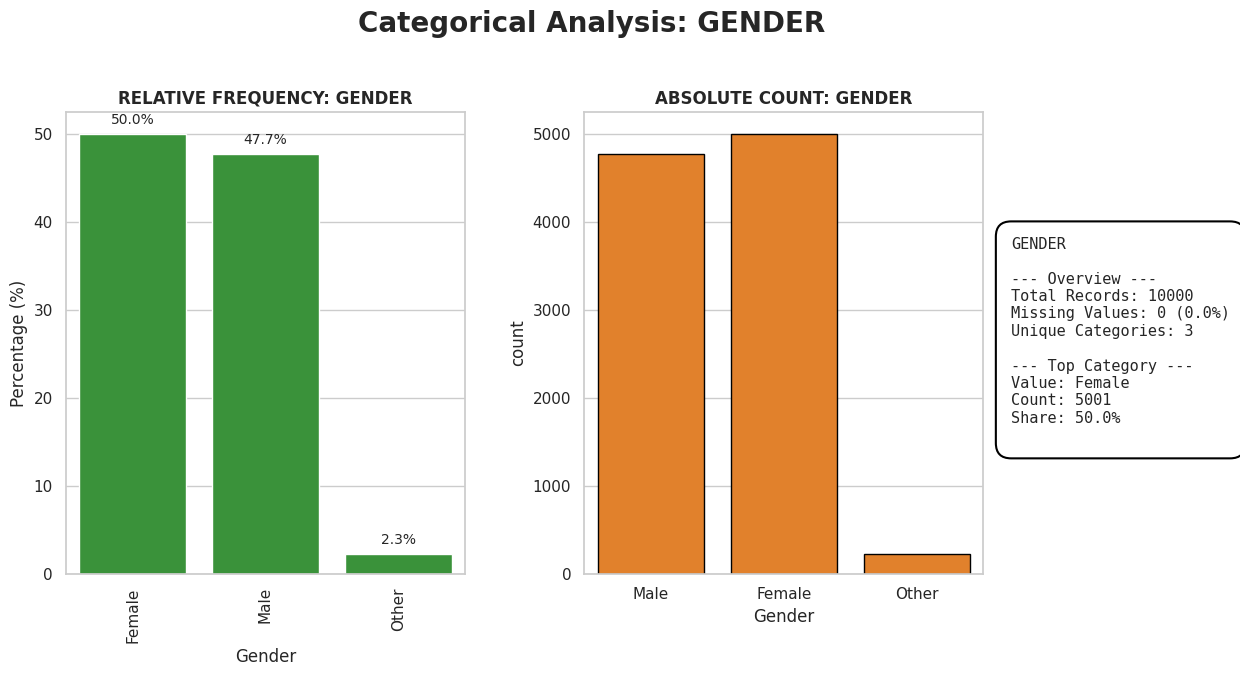

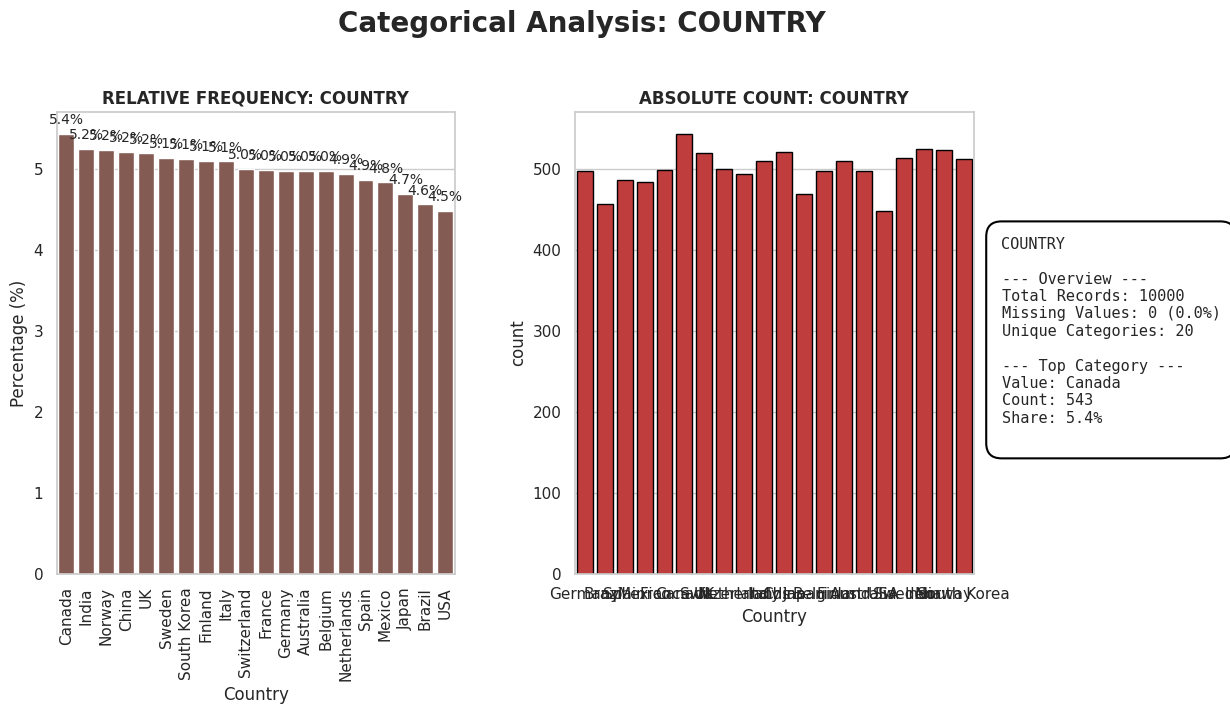

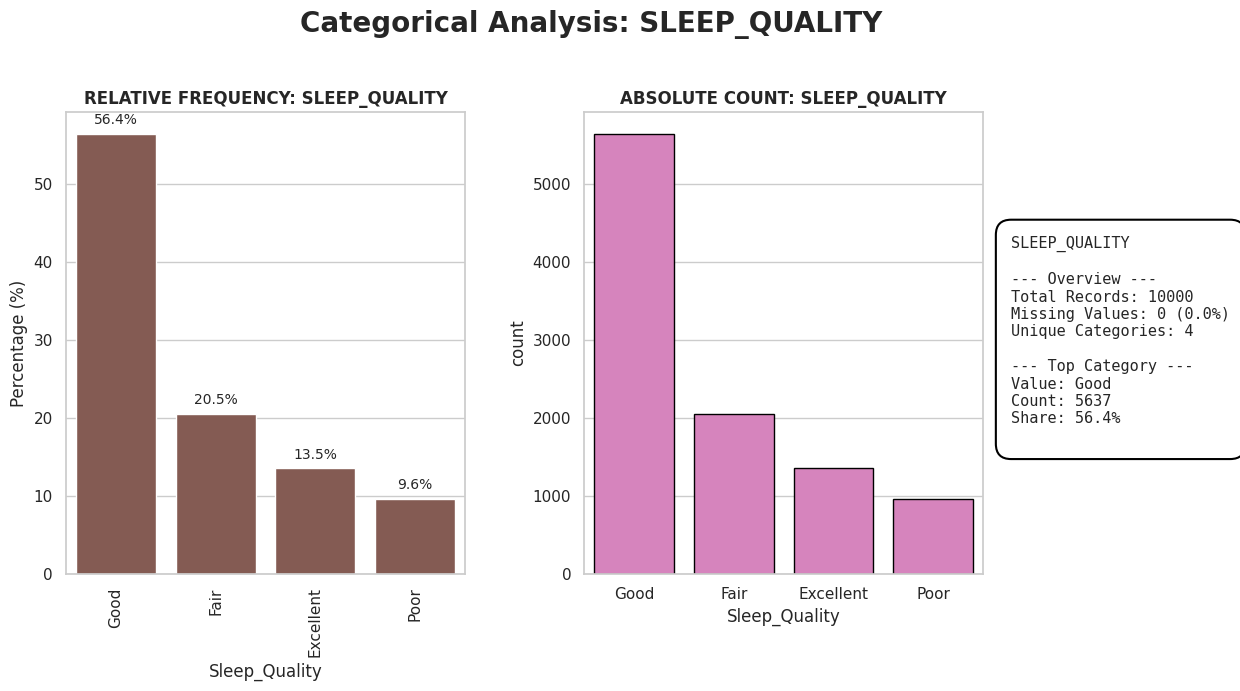

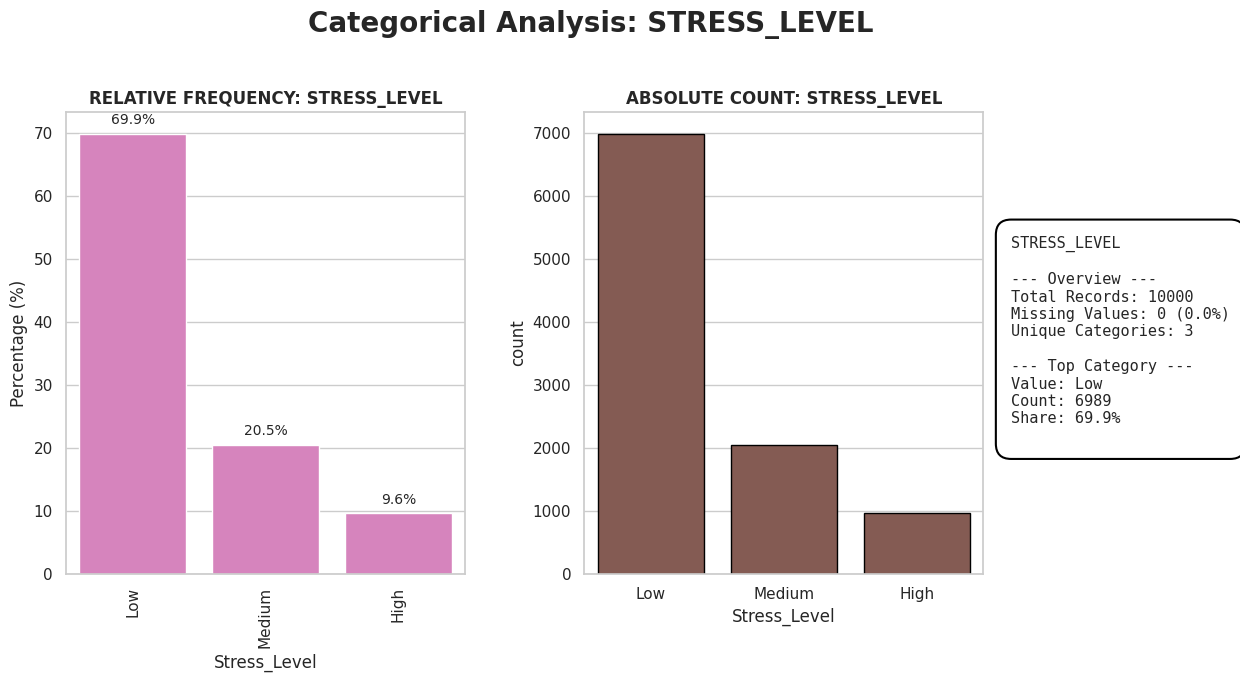

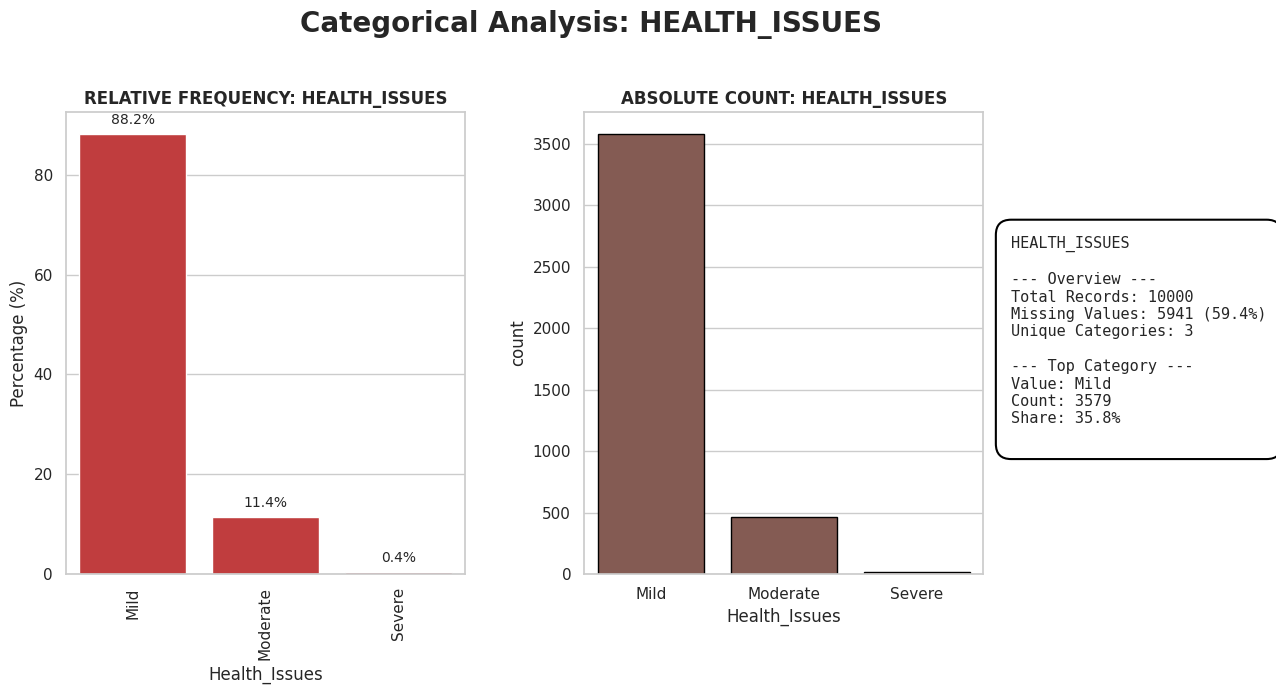

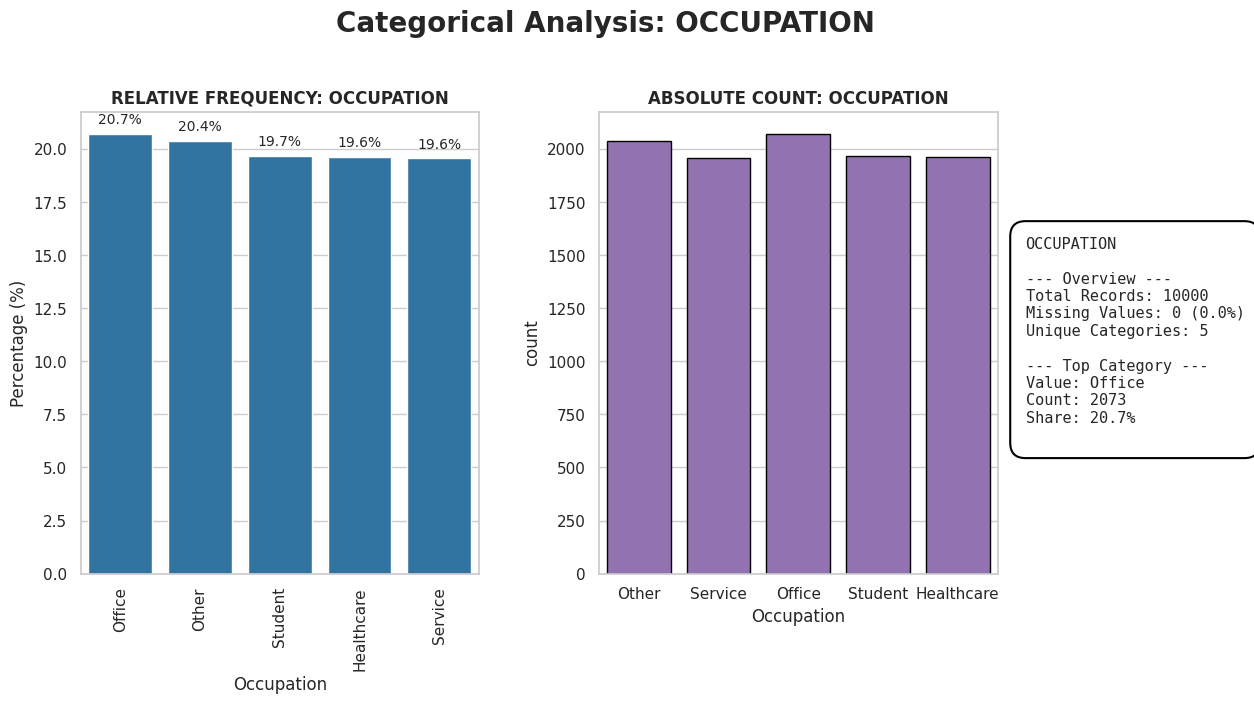

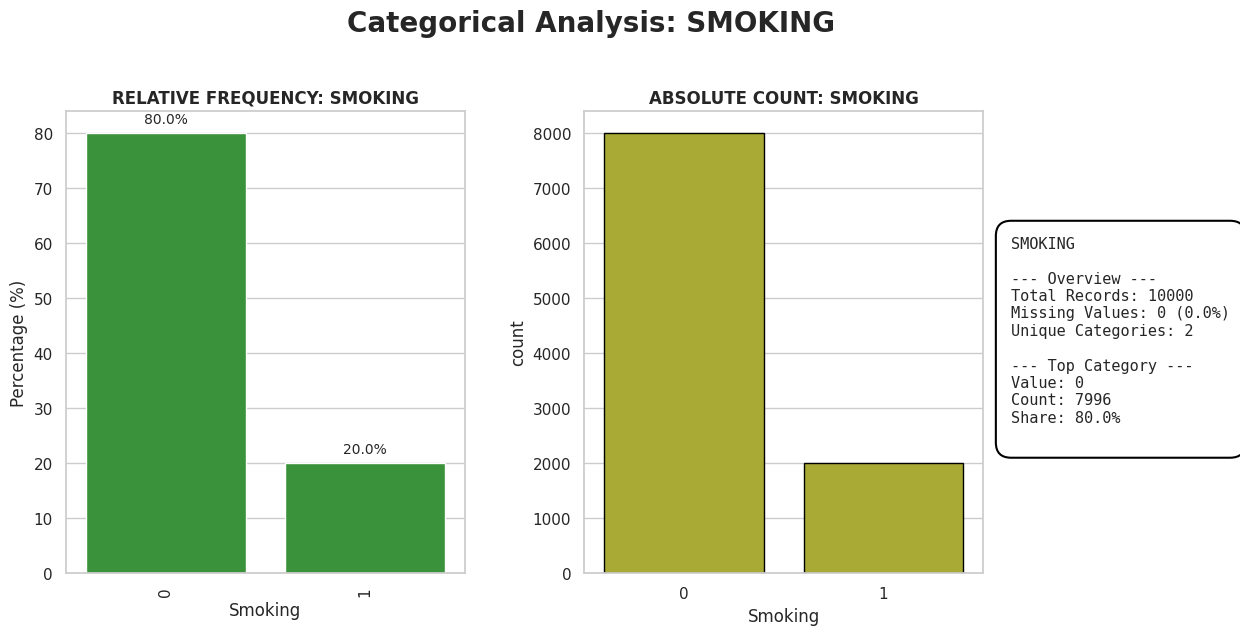

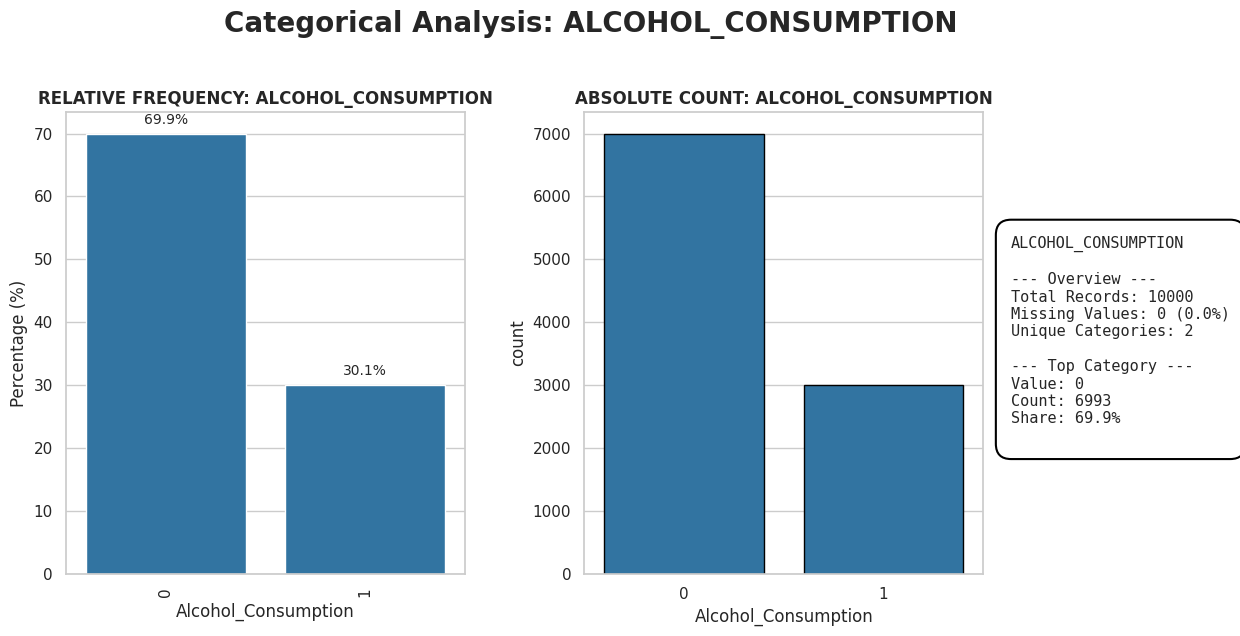

In [ ]:
vizu.generate_categorical_panel(df, variaveis_textuais)

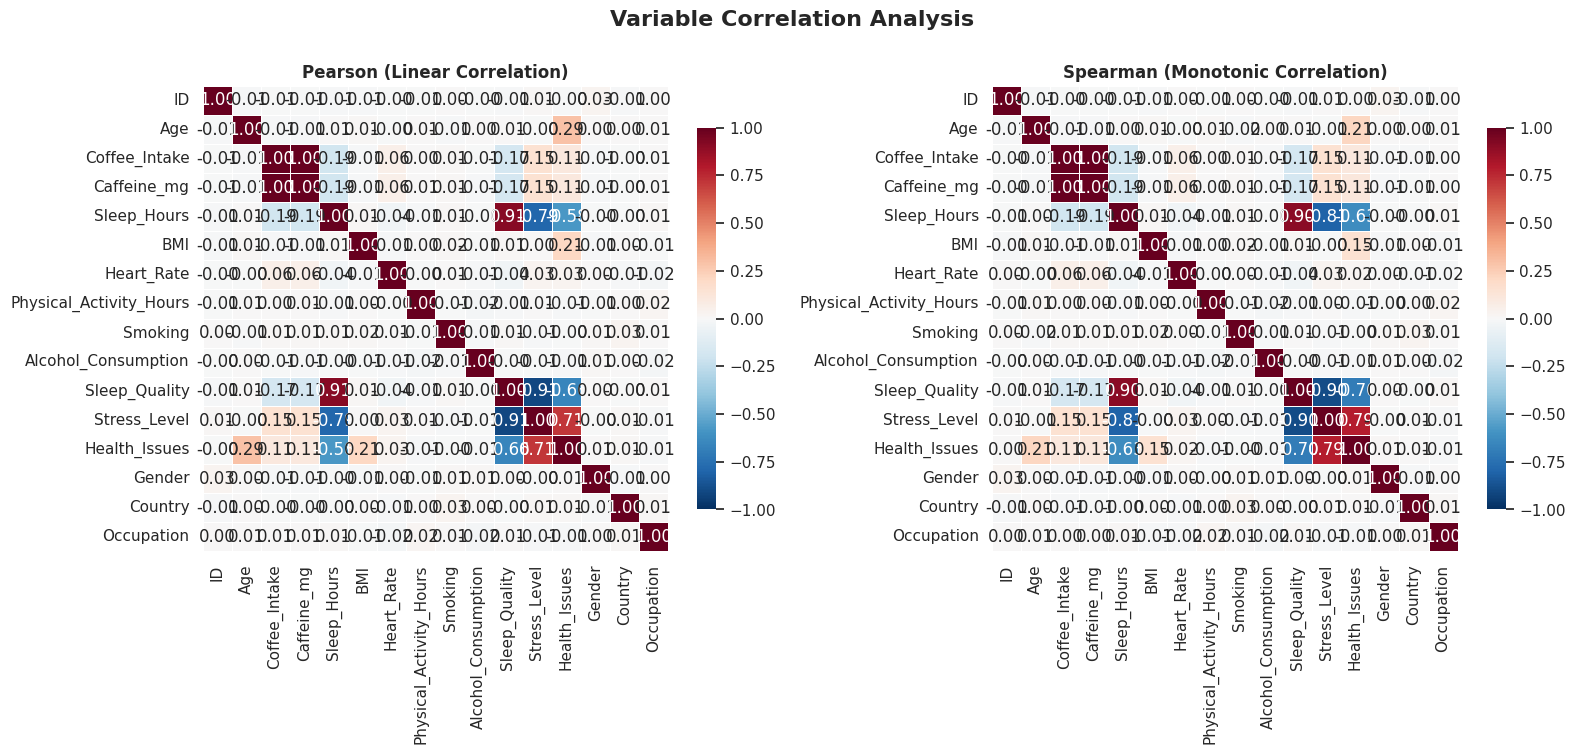

In [ ]:
lista = vizu.plot_correlation_heatmaps(df, variaveis_categoricas)

In [ ]:
print(lista)

            Var1           Var2   Pearson  Spearman
0    Caffeine_mg  Coffee_Intake  0.999814  0.999782
1   Stress_Level    Sleep_Hours -0.793459 -0.805247
2   Stress_Level  Sleep_Quality  0.718162  0.688359
3  Health_Issues            Age  0.297152  0.282849
4  Sleep_Quality    Sleep_Hours -0.256456 -0.272515
5  Health_Issues            BMI  0.235825  0.213048
6    Sleep_Hours    Caffeine_mg -0.190493 -0.190216
7    Sleep_Hours  Coffee_Intake -0.190291 -0.190051
8   Stress_Level    Caffeine_mg  0.149884  0.148678
9   Stress_Level  Coffee_Intake  0.149677  0.148571


## **2.4 TESTES ESTATÍSTICOS**


#### ANÁLISE VARIÁVEIS NUMÉRICAS

In [ ]:
resultados = []

for variavel in variaveis_numericas:
    for grupo in variaveis_categoricas:
        if df[grupo].nunique() == 2:
            r = testes.comparar_dois_grupos(df, variavel, grupo)
        else:
            r, _ = testes.comparar_n_grupos(df, variavel, grupo)
        r["grupo"] = grupo
        resultados.append(r)

tabela = pd.DataFrame(resultados)[
    ["variavel", "grupo", "p_valor", "tamanho_efeito", "magnitude"]
]
_, tabela["p_ajustado"], _, _ = multipletests(tabela["p_valor"], method="fdr_bh")
tabela["relevante"] = (tabela["p_ajustado"] < 0.05) & (tabela["magnitude"] != "DESPREZÍVEL")

tabela.sort_values("tamanho_efeito", ascending=False, key=abs).head(15)


────────────────────────────────────────────────────────────────
Age por Gender — 3 grupos, n=10000
────────────────────────────────────────────────────────────────

  Age por grupo (mediana, do menor para o maior):
    Male 34.00  <  Other 34.00  <  Female 35.00

  Os grupos NÃO diferem em Age (p = 0.806).
  A variação entre eles é compatível com o acaso.

────────────────────────────────────────────────────────────────
Age por Country — 20 grupos, n=10000
────────────────────────────────────────────────────────────────

  Age por grupo (mediana, do menor para o maior):
    India 33.00  <  Belgium 34.00  <  Finland 34.00  <  Germany 34.00  <  Mexico 34.00  <  Spain 34.00  <  UK 34.00  <  USA 34.00  <  Switzerland 34.50  <  Australia 35.00  <  Brazil 35.00  <  Canada 35.00  <  China 35.00  <  France 35.00  <  Italy 35.00  <  Japan 35.00  <  Netherlands 35.00  <  Norway 35.00  <  South Korea 35.00  <  Sweden 35.00

  Os grupos NÃO diferem em Age (p = 0.900).
  A variação entre eles é c

,variavel,grupo,p_valor,tamanho_efeito,magnitude,p_ajustado,relevante
26,Sleep_Hours,Sleep_Quality,0.000000e+00,0.808083,GRANDE,0.000000e+00,True
27,Sleep_Hours,Stress_Level,0.000000e+00,0.648353,GRANDE,0.000000e+00,True
28,Sleep_Hours,Health_Issues,0.000000e+00,0.395728,GRANDE,0.000000e+00,True
4,Age,Health_Issues,4.439891e-147,0.067732,MÉDIA,6.215848e-146,True
36,BMI,Health_Issues,9.513459e-79,0.036190,PEQUENA,1.065507e-77,True
18,Caffeine_mg,Sleep_Quality,9.369475e-66,0.030186,PEQUENA,8.744843e-65,True
10,Coffee_Intake,Sleep_Quality,1.123118e-65,0.030150,PEQUENA,8.984942e-65,True
55,Physical_Activity_Hours,Alcohol_Consumption,5.656025e-02,-0.024007,DESPREZÍVEL,2.111583e-01,False
6,Age,Smoking,1.245751e-01,-0.022137,DESPREZÍVEL,3.654872e-01,False
19,Caffeine_mg,Stress_Level,6.425906e-49,0.022000,PEQUENA,4.498134e-48,True


#### ANÁLISE VARIÁVEIS CATEGÓRICAS

In [ ]:
resultados_cat = []

for var1, var2 in combinations(variaveis_categoricas, 2):
    r, _ = testes.comparar_categoricas(df, var1, var2)
    resultados_cat.append(r)

tabela_cat = pd.DataFrame(resultados_cat)[
    ["variavel", "grupo", "p_valor", "cramers_v", "magnitude"]
]
_, tabela_cat["p_ajustado"], _, _ = multipletests(tabela_cat["p_valor"], method="fdr_bh")

tabela_cat.sort_values("cramers_v", ascending=False).head(15)


────────────────────────────────────────────────────────────────
Gender x Country — tabela 3x20, n=10000
────────────────────────────────────────────────────────────────

  % de cada Country dentro de cada Gender:
    Country  Australia  Belgium  Brazil  Canada  China  Finland  France  Germany  India  Italy  Japan  Mexico  Netherlands  Norway  South Korea  Spain  Sweden  Switzerland   UK  USA
    Gender                                                                                                                                                                           
    Female         4.9      5.2     4.8     5.5    5.4      5.2     4.8      5.0    5.5    4.8    4.7     4.8          5.2     5.0          4.6    4.7     5.3          4.9  5.1  4.7
    Male           5.0      4.8     4.2     5.4    5.0      5.1     5.2      5.0    4.9    5.4    4.6     4.8          4.7     5.6          5.6    4.9     5.0          5.0  5.3  4.3
    Other          4.9      4.0     6.6     3.1    4.9   

,variavel,grupo,p_valor,cramers_v,magnitude,p_ajustado
13,Sleep_Quality,Stress_Level,0.000000,1.000000,GRANDE,0.000000
18,Stress_Level,Health_Issues,0.000000,0.565329,GRANDE,0.000000
14,Sleep_Quality,Health_Issues,0.000000,0.461654,MÉDIA,0.000000
11,Country,Smoking,0.053296,0.054666,DESPREZÍVEL,0.213185
9,Country,Health_Issues,0.023896,0.051643,DESPREZÍVEL,0.133815
7,Country,Sleep_Quality,0.104526,0.048555,DESPREZÍVEL,0.353360
8,Country,Stress_Level,0.295652,0.045914,DESPREZÍVEL,0.521302
10,Country,Occupation,0.316505,0.045095,DESPREZÍVEL,0.521302
12,Country,Alcohol_Consumption,0.639687,0.040327,DESPREZÍVEL,0.770503
0,Gender,Country,0.792772,0.039198,DESPREZÍVEL,0.853754


## **2.3.2 A AUSÊNCIA EM Health_Issues CODIFICA O ALVO**

A coluna tem 5.941 nulos (59,4%). Antes de decidir o tratamento, é preciso verificar se a ausência é aleatória.

In [ ]:
faltante = df["Health_Issues"].isna()

print(f"Nulos: {faltante.sum()} ({faltante.mean():.1%})\n")
print(df.groupby(faltante)["Sleep_Hours"].agg(["min", "max", "mean"]).round(2))
print()
print(pd.crosstab(faltante, df["Sleep_Quality"], normalize="index").round(3))

Nulos: 0 (0.0%)

               min   max  mean
Health_Issues                 
False          3.0  10.0  6.64

Sleep_Quality   Poor   Fair   Good  Excellent
Health_Issues                                
False          0.096  0.205  0.564      0.135


**A ausência não é aleatória.** Entre os registros sem Health_Issues, Sleep_Hours tem mínimo de 6,0h, e a distribuição do alvo é 81% Good e 19% Excellent, com **zero** casos de Fair ou Poor.

Saber que o campo está vazio determina que a classe é Good ou Excellent. Imputar "None" converteria 59% do dataset num marcador de "dormiu 6h ou mais" — exatamente a fronteira entre as classes. Por isso os nulos são mantidos como faltantes e a coluna sai das features.

## **2.5 CONCLUSÃO.**

**Redundância.** **Sleep_Hours**, **Sleep_Quality** e **Stress_Level** carregam a mesma informação (Cramér's V = 1,000 entre as categóricas, tabela diagonal). **Coffee_Intake** e **Caffeine_mg** também coincidem (r = 0,9998) e produzem resultados idênticos em todos os testes.

**Vazamento.** A ausência em **Health_Issues** determina que a classe do alvo é Good ou Excellent. A coluna é descartada da modelagem, e o achado inicial de que ela seria a variável de maior estrutura fica invalidado — a associação era artefato da imputação.

**Sinal remanescente.** **Coffee_Intake** apresenta gradiente monotônico e limpo entre os níveis de **Sleep_Quality** (Excellent 2,0 xícaras; Poor 3,0), com todos os pares diferindo entre si. Mas o efeito é pequeno: epsilon² = 0,030, cerca de 3% da variação explicada. A direção sustenta a hipótese do projeto; a magnitude, não.

**Sem sinal.** **Gender**, **Country**, **Occupation**, **BMI** e **Physical_Activity_Hours** são independentes do alvo. Resultados como **Heart_Rate** × **Sleep_Quality** deram significância com efeito desprezível (epsilon² = 0,001) — efeito do tamanho da amostra, não de relação real.

**Natureza dos dados.** O padrão — poucas fontes de estrutura, todas derivadas umas das outras, e ruído no restante — é característico de dados sintéticos gerados a partir de variáveis-semente. As conclusões valem como demonstração de método, não como evidência sobre a relação real entre café e sono.

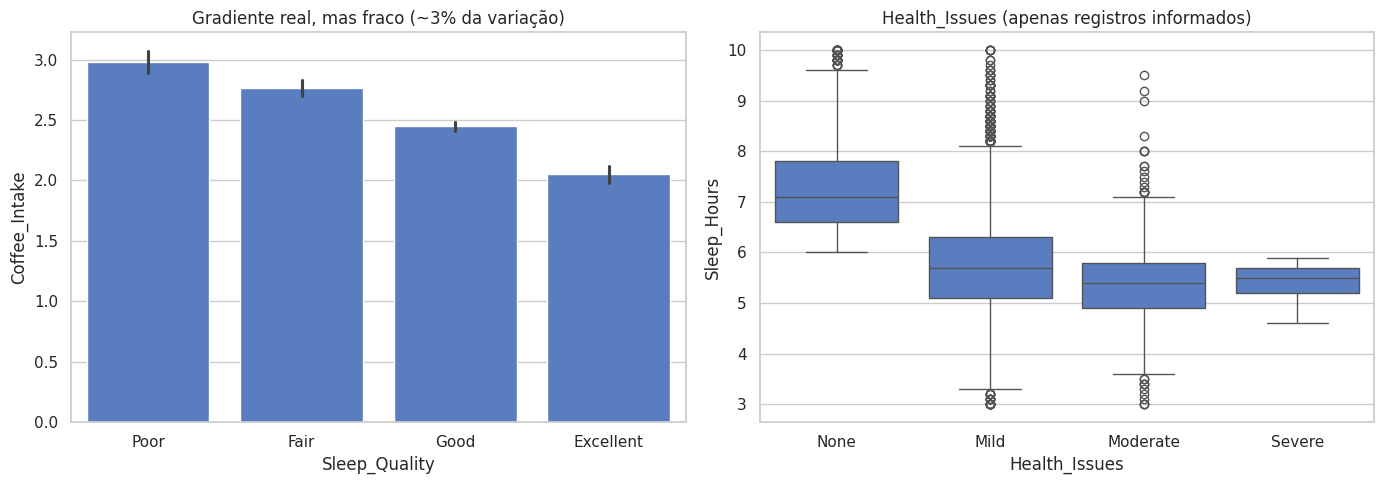

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x="Sleep_Quality", y="Coffee_Intake", errorbar="ci", ax=axes[0])
axes[0].set_title("Gradiente real, mas fraco (~3% da variação)")

sns.boxplot(data=df.dropna(subset="Health_Issues"),
            x="Health_Issues", y="Sleep_Hours", ax=axes[1])
axes[1].set_title("Health_Issues (apenas registros informados)")

plt.tight_layout()

<Axes: xlabel='Stress_Level', ylabel='Sleep_Quality'>

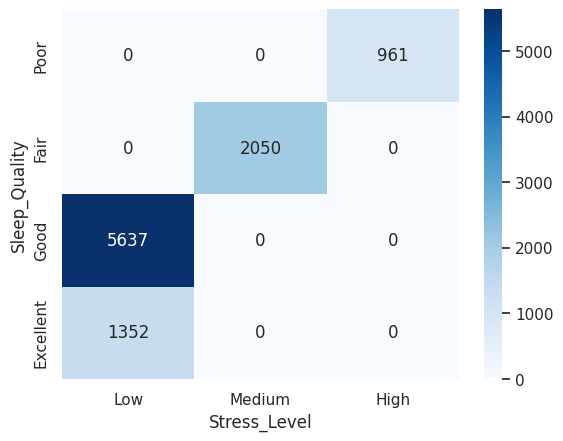

In [ ]:
sns.heatmap(pd.crosstab(df["Sleep_Quality"], df["Stress_Level"]),
            annot=True, fmt="d", cmap="Blues")

<Axes: xlabel='Health_Issues', ylabel='Sleep_Hours'>

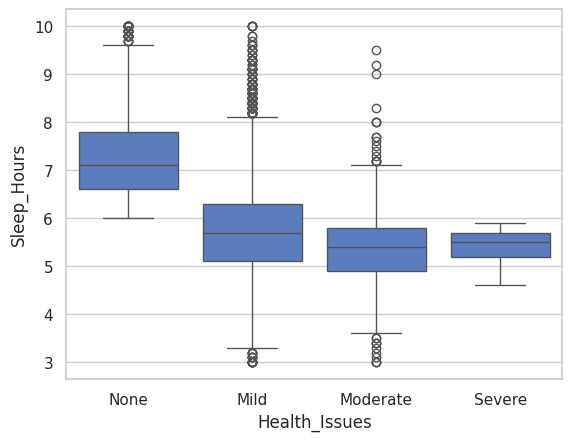

In [ ]:
sns.boxplot(data=df, x="Health_Issues", y="Sleep_Hours")

<Axes: xlabel='Sleep_Quality', ylabel='Coffee_Intake'>

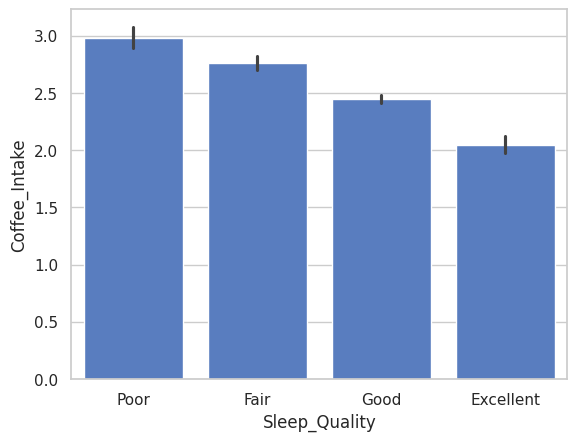

In [ ]:
sns.barplot(data=df, x="Sleep_Quality", y="Coffee_Intake", errorbar="ci")

# **3. PREPARAÇÃO DE DADOS**

In [ ]:
VAZAMENTO = [
    "Sleep_Hours",    # o alvo foi cortado desta coluna (2.3.1)
    "Stress_Level",   # idêntica ao alvo, V = 1,000 (2.3.1)
    "Health_Issues",  # a ausência determina a classe (2.3.2)
]
REDUNDANTES = ["Caffeine_mg"]   # múltiplo de Coffee_Intake, r = 0,9998
SEM_INFO    = ["ID"]

dados = df.drop(columns=VAZAMENTO + REDUNDANTES + SEM_INFO).copy()

# LightGBM trata categóricas nativamente — preserva informação que
# 19 dummies de Country fragmentariam.
for col in ["Gender", "Country", "Occupation"]:
    dados[col] = dados[col].astype("category")

# .cat.codes reaproveita a ordem do CategoricalDtype: Poor=0 ... Excellent=3.
# O .map() devolveria outra Categorical, que o LightGBM rejeita.
y = dados[ALVO].cat.codes.astype(int)
X = dados.drop(columns=[ALVO])

assert (y >= 0).all(), "Há valores nulos no alvo."

print(f"X: {X.shape[0]} linhas x {X.shape[1]} colunas")
print(f"Features: {', '.join(X.columns)}")
print(f"\nDistribuição do alvo:\n{y.value_counts().sort_index().rename(dict(enumerate(CLASSES)))}")

X: 10000 linhas x 10 colunas
Features: Age, Gender, Country, Coffee_Intake, BMI, Heart_Rate, Physical_Activity_Hours, Occupation, Smoking, Alcohol_Consumption

Distribuição do alvo:
Poor          961
Fair         2050
Good         5637
Excellent    1352
Name: count, dtype: int64


# **4. MODELAGEM**

As classes são desbalanceadas (Good tem 5.637 casos, Poor tem 961). Por isso:

- a métrica é **F1-macro**, que pesa todas as classes igualmente — acurácia premiaria um modelo que só prevê Good;
- class_weight="balanced" força o modelo a considerar as minoritárias;
- o DummyClassifier estabelece o piso de comparação;
- o early stopping usa um conjunto de **validação separado**, não o teste — caso contrário o teste influenciaria o número de árvores e o resultado seria otimista.

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=.25, random_state=42, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=.2, random_state=42, stratify=y_tr)

print(f"Treino: {len(X_tr)} | Validação: {len(X_val)} | Teste: {len(X_te)}\n")

baseline = DummyClassifier(strategy="stratified", random_state=42).fit(X_tr, y_tr)
f1_baseline = f1_score(y_te, baseline.predict(X_te), average="macro")
print(f"Baseline (chute estratificado): F1-macro = {f1_baseline:.3f}")

modelo = lgb.LGBMClassifier(
    objective="multiclass", num_class=4,
    n_estimators=3000, learning_rate=0.05,
    num_leaves=31, min_child_samples=30,
    class_weight="balanced", random_state=42, verbose=-1,
)
modelo.fit(X_tr, y_tr,
           eval_X=X_val, eval_y=y_val,
           eval_metric="multi_logloss",
           callbacks=[lgb.early_stopping(50, verbose=False)])

f1_modelo = f1_score(y_te, modelo.predict(X_te), average="macro")
print(f"LightGBM: F1-macro = {f1_modelo:.3f}  (árvores: {modelo.best_iteration_})")
print(f"Ganho sobre o baseline: {f1_modelo - f1_baseline:+.3f}")

Treino: 6000 | Validação: 1500 | Teste: 2500

Baseline (chute estratificado): F1-macro = 0.245
LightGBM: F1-macro = 0.273  (árvores: 364)
Ganho sobre o baseline: +0.028


# **5. AVALIAÇÃO**

In [ ]:
print(classification_report(y_te, modelo.predict(X_te),
                            target_names=CLASSES, zero_division=0))

              precision    recall  f1-score   support

        Poor       0.11      0.10      0.11       240
        Fair       0.23      0.24      0.23       513
        Good       0.56      0.56      0.56      1409
   Excellent       0.19      0.19      0.19       338

    accuracy                           0.40      2500
   macro avg       0.27      0.27      0.27      2500
weighted avg       0.40      0.40      0.40      2500



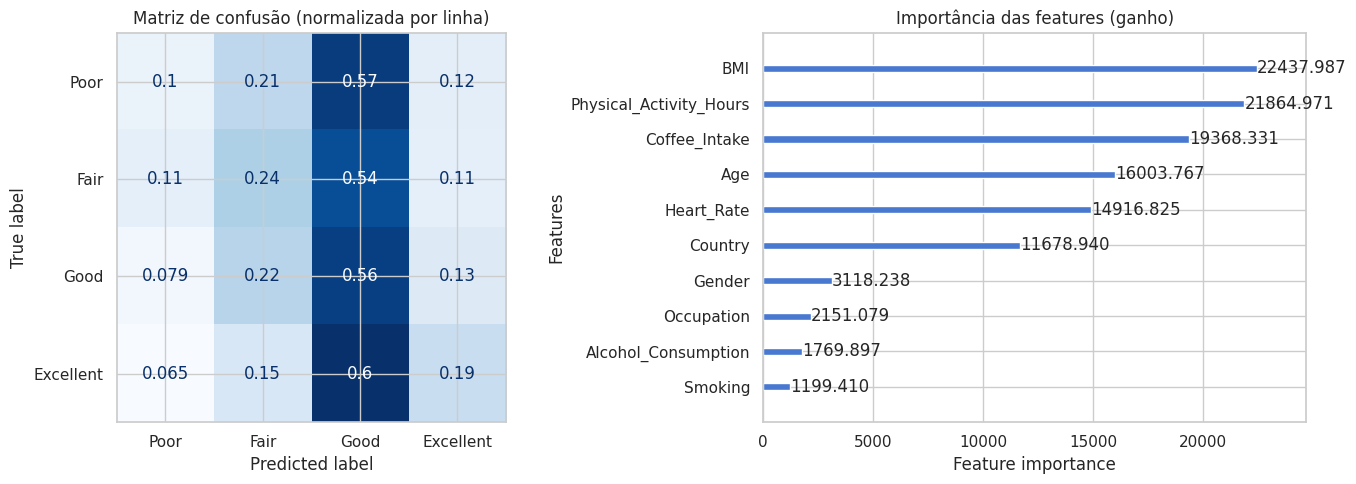

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    modelo, X_te, y_te, display_labels=CLASSES,
    normalize="true", cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusão (normalizada por linha)")

lgb.plot_importance(modelo, max_num_features=10, importance_type="gain", ax=axes[1])
axes[1].set_title("Importância das features (ganho)")

plt.tight_layout()